### Problem 2: Building a Random Forest from Scratch

In this problem you will implement the core logic of a random forest by hand, then verify your results against sklearn. This is the ensemble analog of the from-scratch neural network in Problem 2 of the Module 5 homework.

Use the two moons dataset. Split into 70% train / 30 % test with random_state = 0. 

(a). $\bf{Bootstrap \: sampling}$. Write a function that draws a bootstrap of size N from a dataset of size N (sampling with replacement). Generate 5 bootstrap samples from the training set. For each, report the fraction of unique training points included. Verify that this is close to 1-1/e $\approx$ 63.2%.

In [38]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import make_moons
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score

RNG = np.random.default_rng(0)

x, y = make_moons(n_samples=300, noise=0.3, random_state=42)
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.3, random_state=0)

In [39]:
def bootstrap_sample(X, y, rng):
    n = len(y)
    idx = rng.choice(n, size=n, replace=True) # pick n indices from 0 to n-1
    return X[idx], y[idx], idx # create dataset

print("Part (a): Bootstrap sampling:")

# Generate 5 bootstrap samples of size N
for b in range(5):
    X_boot, y_boot, idx = bootstrap_sample(x_train, y_train, RNG)
    frac_unique = len(np.unique(idx)) / len(y_train) # divide distinct sampled indices by total # of training points
    print(f"Sample {b+1}: {frac_unique:.3f} unique points")

print(f"Verification: ~{1 - 1/np.e:.3f}")

Part (a): Bootstrap sampling:
Sample 1: 0.662 unique points
Sample 2: 0.619 unique points
Sample 3: 0.638 unique points
Sample 4: 0.624 unique points
Sample 5: 0.643 unique points
Verification: ~0.632


(b). $\bf{Train \: individual \: trees}$. Train a DecisionTreeClassifier on each of the 5 bootstrap samples. Report the test accuracy of each individual tree.

In [40]:
print("\nPart (b): Individual trees")

trees = [] # to store each trained model 
tree_accs = [] # to store each tree's test accuracy

for b in range(5):
    x_boot, y_boot, _ = bootstrap_sample(x_train, y_train, RNG)

    tree = DecisionTreeClassifier(
        max_depth=None,
        max_features='sqrt', # make each tree consider only a random subset of features at every split
        random_state=b
    )
    tree.fit(x_boot, y_boot)

    acc = tree.score(x_test, y_test)

    trees.append(tree)
    tree_accs.append(acc)

    print(f"Tree {b}: test accuracy = {acc:.3f}")


Part (b): Individual trees
Tree 0: test accuracy = 0.867
Tree 1: test accuracy = 0.789
Tree 2: test accuracy = 0.822
Tree 3: test accuracy = 0.867
Tree 4: test accuracy = 0.878


(c). $\bf{Majority \: vote.}$ For each test sample, collect the predictions of all 5 trees and take the majority vote. Report the ensemble's test accuracy. Is it better than the average individual tree accuracy? Is it better than the best individual tree?


In [41]:
print("\nPart (c): Majority vote")

all_preds = np.array([tree.predict(x_test) for tree in trees])

majority_vote = (np.mean(all_preds, axis=0) >= 0.5).astype(int)
ensemble_acc = accuracy_score(y_test, majority_vote)
individual_accs = [tree.score(x_test, y_test) for tree in trees]

print(f'Individual tree accuracies: {["{:.1%}".format(a) for a in individual_accs]}')
print(f'Mean individual accuracy:   {np.mean(individual_accs):.1%}')
print(f'Best individual accuracy:   {np.max(individual_accs):.1%}')
print(f'Ensemble (majority vote):   {ensemble_acc:.1%}')

print("\nConclusion:")
print("Better than average tree?", ensemble_acc > np.mean(individual_accs))
print("Better than best tree?", ensemble_acc > np.max(individual_accs))


Part (c): Majority vote
Individual tree accuracies: ['86.7%', '78.9%', '82.2%', '86.7%', '87.8%']
Mean individual accuracy:   84.4%
Best individual accuracy:   87.8%
Ensemble (majority vote):   88.9%

Conclusion:
Better than average tree? True
Better than best tree? True


(d). $\bf{Scaling \: up.}$ Repeat parts (a) - (c) for B = 1, 5, 20, 25, 50, 100, 200 trees. Plot the ensemble test accuracy vs. B. On the same plot, show the accuracy of sklearn.ensemble.RandomForestClassifier with the same number of estimators. Do they agree?

In [42]:
print("\nPart (d): Scaling up")

B_vals = [1, 5, 10, 25, 50, 100, 200]

og_accs = []
sk_accs = []

for B in B_vals:
    trees = []
    predictions = []

    # Training B bootstrap trees
    for b in range(B):
        x_boot, y_boot, _ = bootstrap_sample(x_train, y_train, RNG)

        tree = DecisionTreeClassifier(
            max_depth=None,
            max_features='sqrt',
            random_state=b
        )
        tree.fit(x_boot, y_boot)

        trees.append(tree)
        predictions.append(tree.predict(x_test))

    predictions = np.array(predictions)

    ensemble_pred = (np.mean(predictions, axis=0) >= 0.5).astype(int)
    ensemble_acc = accuracy_score(y_test, ensemble_pred)
    og_accs.append(ensemble_acc)

    # sklearn random forest classifier
    rf = RandomForestClassifier(
        n_estimators=B,
        max_depth=None,
        max_features='sqrt',
        bootstrap=True,
        random_state=0
    )
    rf.fit(x_train, y_train)

    rf_acc = rf.score(x_test, y_test)
    sk_accs.append(rf_acc)

    print(f"B = {B:3d} | scratch = {ensemble_acc:.3f} | sklearn = {rf_acc:.3f}")


Part (d): Scaling up
B =   1 | scratch = 0.844 | sklearn = 0.856
B =   5 | scratch = 0.856 | sklearn = 0.844
B =  10 | scratch = 0.856 | sklearn = 0.844
B =  25 | scratch = 0.867 | sklearn = 0.889
B =  50 | scratch = 0.889 | sklearn = 0.867
B = 100 | scratch = 0.867 | sklearn = 0.867
B = 200 | scratch = 0.844 | sklearn = 0.867


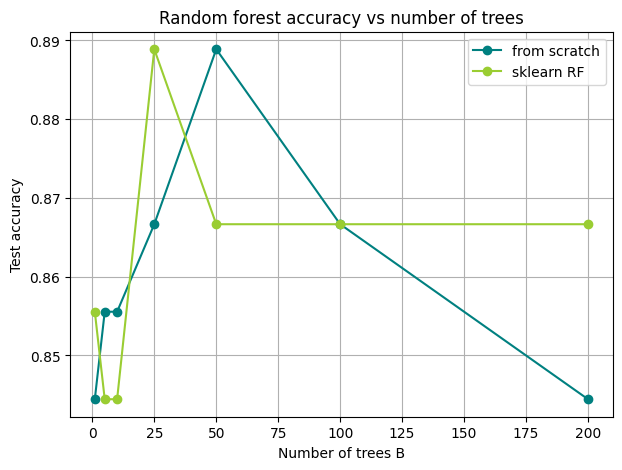

In [43]:
import matplotlib.colors as mcolors

plt.figure(figsize=(7, 5))
plt.plot(B_vals, og_accs, marker='o', color= 'teal', label='from scratch')
plt.plot(B_vals, sk_accs, marker='o', color= 'yellowgreen', label='sklearn RF')

plt.xlabel("Number of trees B")
plt.ylabel("Test accuracy")
plt.title("Random forest accuracy vs number of trees")
plt.legend()
plt.grid(True)
plt.show()

The hand-built ensemble and sklearn’s RandomForestClassifier show similar trends in test accuracy as the number of trees increases. There are a few reasons why the exact accuracies may differ. First, the bootstrap samples are generated using different random processes, so the models are trained on different datasets. Also, the hand-built ensemble uses random_state = b, which introduces additional randomness inside the tree. Sklearn’s RandomForestClassifier uses a single random_state to initialize the overall random number generator, and then generates different randomness for each tree internally. Therefore, it is not possible to directly assign a separate random_state to each tree in sklearn in the same way. There are also different tree structures because sklearn randomly selects features at every split and uses optimized internal sampling.

(e) $\bf{Discussion}$

The term that is reduced by increasing $B$ is
    $$
    \frac{1 - \rho}{B}\sigma^2,
    $$
    
since it decreases proportionally to $1/B$ and approaches 0 as B to $\infty$.

(ii). The parameter max_features='sqrt' reduces the correlation $\rho$ between trees by forcing each tree to consider only a random subset of features at each split. This increases diversity among the trees and decreases the term $\rho \sigma^2$, which cannot be reduced by increasing $B$.

(iii). The ensemble accuracy plateaus because increasing $B$ only reduces the variance term
    $$
    \frac{1 - \rho}{B}\sigma^2,
    $$
    which approaches zero as $B$ increases. The remaining term $\rho \sigma^2$, due to correlation between trees, cannot be eliminated. Therefore, beyond a certain point, adding more trees does not significantly improve performance.

### Problem 3: Gradient Boosting and Overfitting
Use the same moons dataset and train/test split from Problem 2.

(a) $\bf{Boosting \: Learning \: Curves.}$

In [44]:
from sklearn.ensemble import GradientBoostingClassifier

gb = GradientBoostingClassifier(
    n_estimators=500,
    learning_rate=0.1,
    max_depth=3,
    random_state=0
)

gb.fit(x_train, y_train)

train_accs = []
test_accs = []

# Use staged_predict to compute the train and test accuracy at every boosting round
for y_pred_train in gb.staged_predict(x_train):
    train_accs.append(accuracy_score(y_train, y_pred_train))

for y_pred_test in gb.staged_predict(x_test):
    test_accs.append(accuracy_score(y_test, y_pred_test))

rounds = np.arange(1, 501)

best_round = np.argmax(test_accs) + 1
best_test_acc = np.max(test_accs)

print("Part (a):")
print(f"The best test accuracy = {best_test_acc:.3f}, which occurs at boosting round {best_round}.")

Part (a):
The best test accuracy = 0.889, which occurs at boosting round 7.


(b) $\bf{Random \: Forest \: Comparison.}$

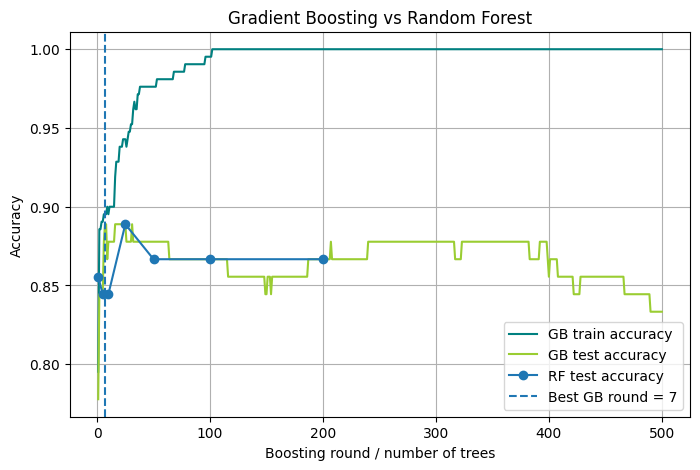

No, the random forest curve does not decrease, but instead plateaus.


In [46]:
# parts a and b

plt.figure(figsize=(8, 5))
plt.plot(rounds, train_accs, label="GB train accuracy", color="teal")
plt.plot(rounds, test_accs, label="GB test accuracy", color="yellowgreen")
plt.plot(B_vals, sk_accs, marker='o', label="RF test accuracy")

plt.axvline(best_round, linestyle='--', label=f"Best GB round = {best_round}")

plt.xlabel("Boosting round / number of trees")
plt.ylabel("Accuracy")
plt.title("Gradient Boosting vs Random Forest")
plt.legend()
plt.grid(True)
plt.show()

print("No, the random forest curve does not decrease, but instead plateaus.")

#### In 2-3 sentences, explain why boosting can overfit with more trees while bagging cannot.

Boosting can overfit because each new tree is trained to correct the errors of the current ensemble, so adding too many trees can make the model fit noise in the training data. On the other hand, bagging averages many independently trained trees, which mainly reduces variance and does not keep pushing the model to correct residual errors in the same way. As a result, random forest performance usually plateaus rather than decreasing substantially as more trees are added.

(c). $\bf{Connection \: to \: Gradient \: Descent}$. What plays the role of the "learning rate" in each case? What plays the role of the "number of steps"? Why does the same overfitting risk (too many steps with too high a rate) appear in both?

Gradient boosting is analogous to gradient descent because each new tree is added in the direction that reduces the loss, just as each weight update in a neural network moves in the negative gradient direction. In boosting, the learning rate controls how much each tree contributes, while in neural networks the learning rate controls the size of each parameter update. The number of boosting rounds plays the role of the number of optimization steps. In both cases, taking too many steps or using too large a learning rate can lead to overfitting, because the model starts fitting noise instead of just the underlying pattern.